# FT-NIR Glucose w/w analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from clustering import plot_PCA, plot_PHATE, plot_UMAP, plot_TSNE

## Load Data

In [15]:
mean_fs_data = pd.read_csv('../data/data_processing/mean_data.csv', index_col=0)
fs_data = pd.read_csv('../data/data_processing/processed_data.csv', index_col=0)
mean_food_data = pd.read_csv('../data/data_processing/mean_foods_data.csv', index_col=0)
foods_data = pd.read_csv('../data/data_processing/processed_foods_data.csv', index_col=0)
fs_data

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.0,0.368909,0.371250,0.365693,0.365159,0.360829,0.357576,0.355040,0.356554,0.354889,0.347379,...,0.184542,0.178153,0.177718,0.180572,0.173209,0.168235,0.171978,0.176712,0.172280,0.168966
0.0,0.174039,0.171243,0.155967,0.157244,0.160958,0.160517,0.163248,0.159695,0.159699,0.164543,...,0.148533,0.146436,0.142626,0.145708,0.151303,0.145216,0.132038,0.135004,0.136618,0.140038
0.0,0.136935,0.121657,0.128571,0.139961,0.128281,0.116669,0.125559,0.130501,0.128288,0.118640,...,0.061725,0.052813,0.050689,0.058184,0.062055,0.062467,0.065904,0.058885,0.050026,0.049251
0.0,0.406242,0.400763,0.402500,0.402956,0.405200,0.405639,0.394606,0.392809,0.388402,0.392009,...,0.068231,0.065292,0.067868,0.072777,0.068126,0.062028,0.065154,0.067731,0.067351,0.065652
0.0,0.362856,0.353994,0.346843,0.346984,0.347116,0.345381,0.343901,0.345708,0.334150,0.325251,...,0.142166,0.144459,0.144330,0.146200,0.151574,0.146458,0.141956,0.135055,0.132481,0.141057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.0,0.555258,0.556772,0.560092,0.556223,0.554091,0.554223,0.552431,0.560476,0.564071,0.570377,...,0.062581,0.061989,0.061168,0.060477,0.058960,0.063098,0.066309,0.062699,0.063096,0.061129
1.0,0.586003,0.593413,0.589558,0.598289,0.603600,0.606577,0.610223,0.606317,0.603439,0.606896,...,0.123145,0.124818,0.124524,0.126314,0.127380,0.129594,0.127124,0.126583,0.124586,0.125121
1.0,0.579945,0.592876,0.584950,0.580428,0.582088,0.575230,0.575615,0.583541,0.583483,0.592932,...,0.080313,0.077472,0.077117,0.078712,0.079774,0.082540,0.079884,0.077831,0.076295,0.074526
1.0,0.570594,0.573988,0.576377,0.572245,0.578236,0.583994,0.586108,0.586958,0.589191,0.591778,...,0.045519,0.042929,0.042077,0.044491,0.044328,0.043269,0.042787,0.042323,0.040255,0.040373


In [18]:
labels = [0, 0.15, 0.25, 0.35, 0.45, 0.5, 0.75, 1]
food_labels = ["buttermilk_biscuit", "inst_potatoes", "mixed_gravy", "nonfat_milk", "parmesan", "protein_pancake", "tapioca"]
waves = [float(col) for col in fs_data.columns]

## Visualize Spectra

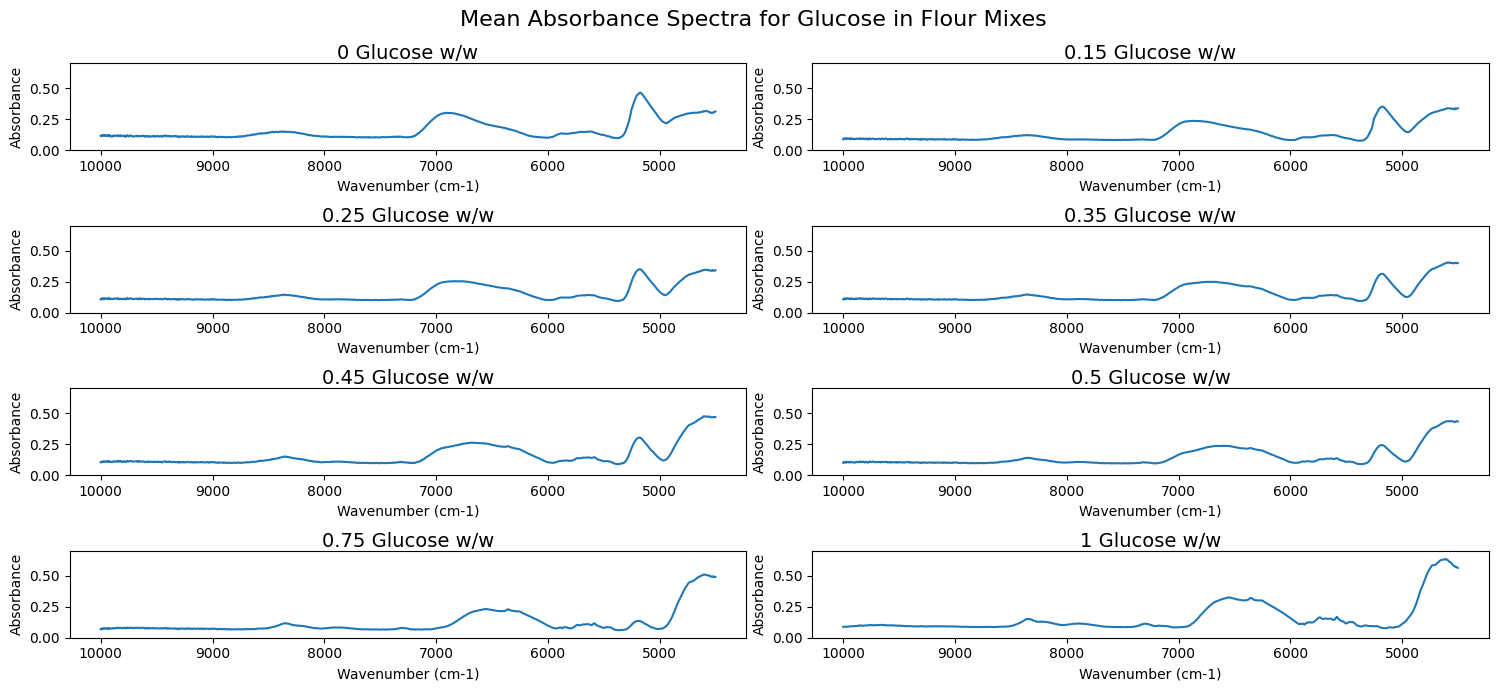

In [10]:
fig, axs = plt.subplots(4,2, figsize=(15,7))
# panels = ["A.", "B.", "C.", "D."]
for i, ax in enumerate(axs.flatten()):
    ax.plot(waves, mean_fs_data.loc[labels[i]], label=str(labels[i])+" Mean")
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(f'{labels[i]} Glucose w/w', y=0.95, fontsize=14)
    # ax.annotate(panels[i], xy=(0.02, 0.99), xycoords='axes fraction', fontsize=14, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_ylim(0,0.7)
    # ax.legend(loc='lower right')
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)
plt.tight_layout()
plt.show()

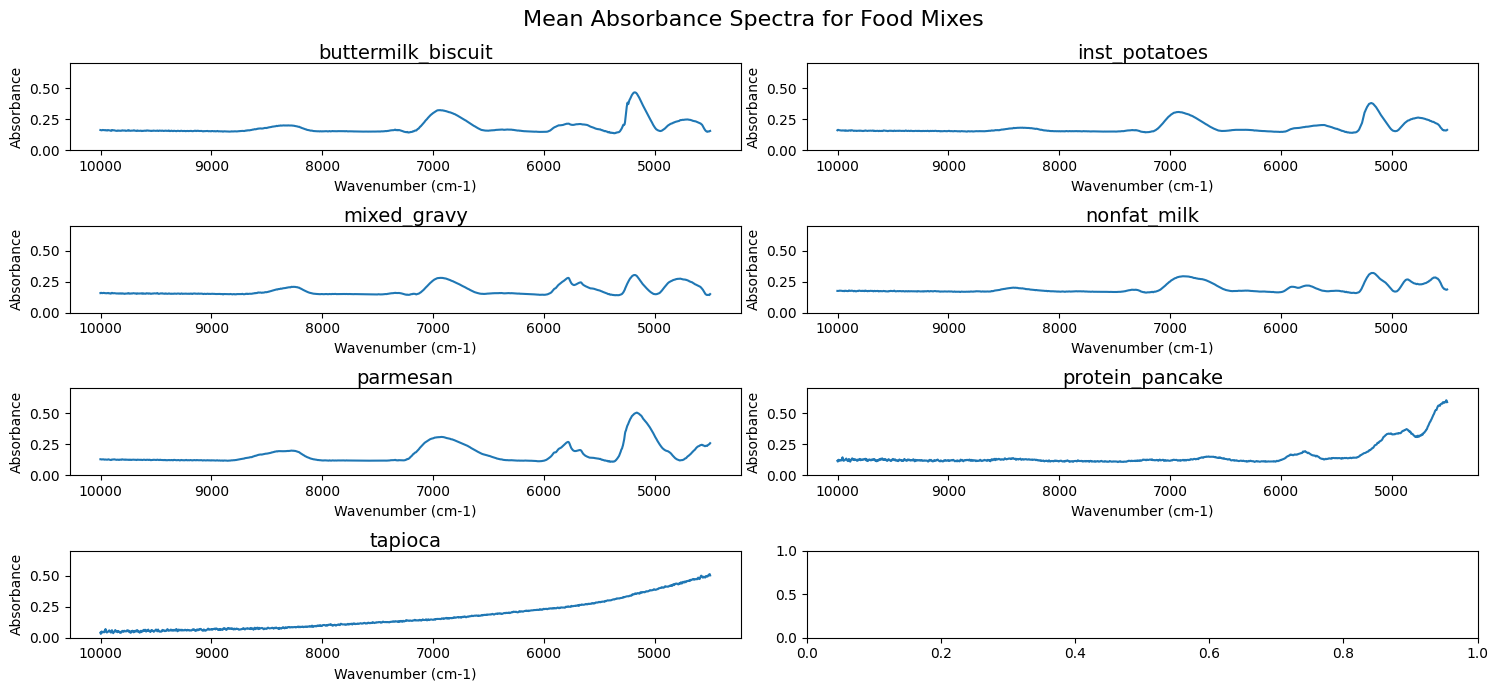

In [23]:
fig, axs = plt.subplots(4,2, figsize=(15,7))
# panels = ["A.", "B.", "C.", "D."]
for i, ax in enumerate(axs.flatten()):
    if i == len(food_labels):
        break
    ax.plot(waves, mean_food_data.loc[food_labels[i]], label=str(labels[i])+" Mean")
    ax.set_xlabel("Wavenumber (cm-1)")
    ax.set_ylabel("Absorbance")
    ax.set_title(food_labels[i], y=0.95, fontsize=14)
    # ax.annotate(panels[i], xy=(0.02, 0.99), xycoords='axes fraction', fontsize=14, fontweight='bold', va='top')
    ax.invert_xaxis()
    ax.set_ylim(0,0.7)
    # ax.legend(loc='lower right')
fig.suptitle('Mean Absorbance Spectra for Food Mixes', fontsize=16)
plt.tight_layout()
plt.show()

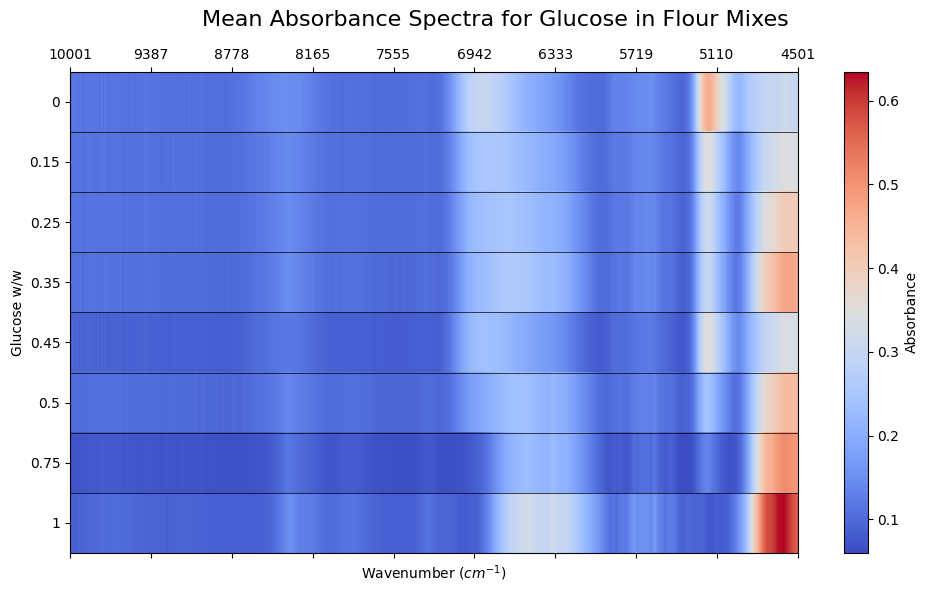

In [31]:
fig, ax = plt.subplots(figsize=(10,6))
mat = ax.matshow(mean_fs_data.values, cmap='coolwarm', aspect='auto')

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.linspace(0, len(waves) - 1, num=10))
ax.set_xticklabels([int(waves[int(i)]) for i in np.linspace(0, len(waves) - 1, num=10)])

ax.invert_xaxis()
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel("Glucose w/w")

ax.hlines(np.arange(len(labels)-1)+0.5, xmin=0, xmax=len(waves)-1, colors='k', linewidth=0.5)

fig.colorbar(mat, ax=ax, label="Absorbance")
fig.suptitle('Mean Absorbance Spectra for Glucose in Flour Mixes', fontsize=16)

plt.tight_layout()
plt.show()

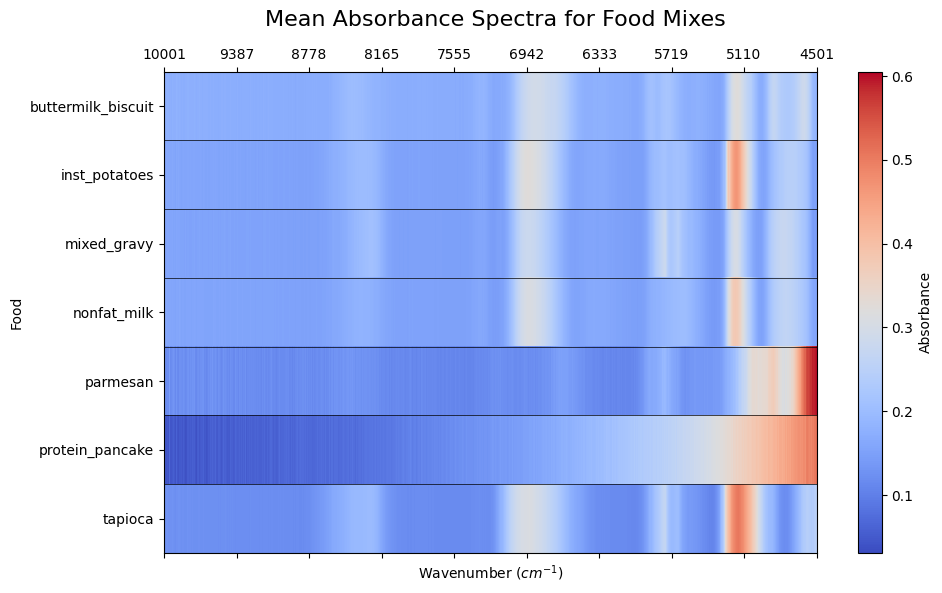

In [32]:
fig, ax = plt.subplots(figsize=(10,6))
mat = ax.matshow(mean_food_data.values, cmap='coolwarm', aspect='auto')

ax.set_yticks(np.arange(len(food_labels)))
ax.set_yticklabels(food_labels)
ax.set_xticks(np.linspace(0, len(waves) - 1, num=10))
ax.set_xticklabels([int(waves[int(i)]) for i in np.linspace(0, len(waves) - 1, num=10)])

ax.invert_xaxis()
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel("Food")

ax.hlines(np.arange(len(labels)-1)+0.5, xmin=0, xmax=len(waves)-1, colors='k', linewidth=0.5)

fig.colorbar(mat, ax=ax, label="Absorbance")
fig.suptitle('Mean Absorbance Spectra for Food Mixes', fontsize=16)

plt.tight_layout()
plt.show()

## ML Clustering

In [35]:
#read the data
n = len(fs_data.columns)
X_features = fs_data.iloc[:, 1:n]
y_label = fs_data.index

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 167 samples in 0.000s...
[t-SNE] Computed neighbors for 167 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 167 / 167
[t-SNE] Mean sigma: 0.987271
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.744427
[t-SNE] KL divergence after 800 iterations: 0.261984
Calculating PHATE...
  Running PHATE on 167 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.02 seconds.
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.02 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -3.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.07 seconds.
Calculated PHATE in 0.10 seconds.


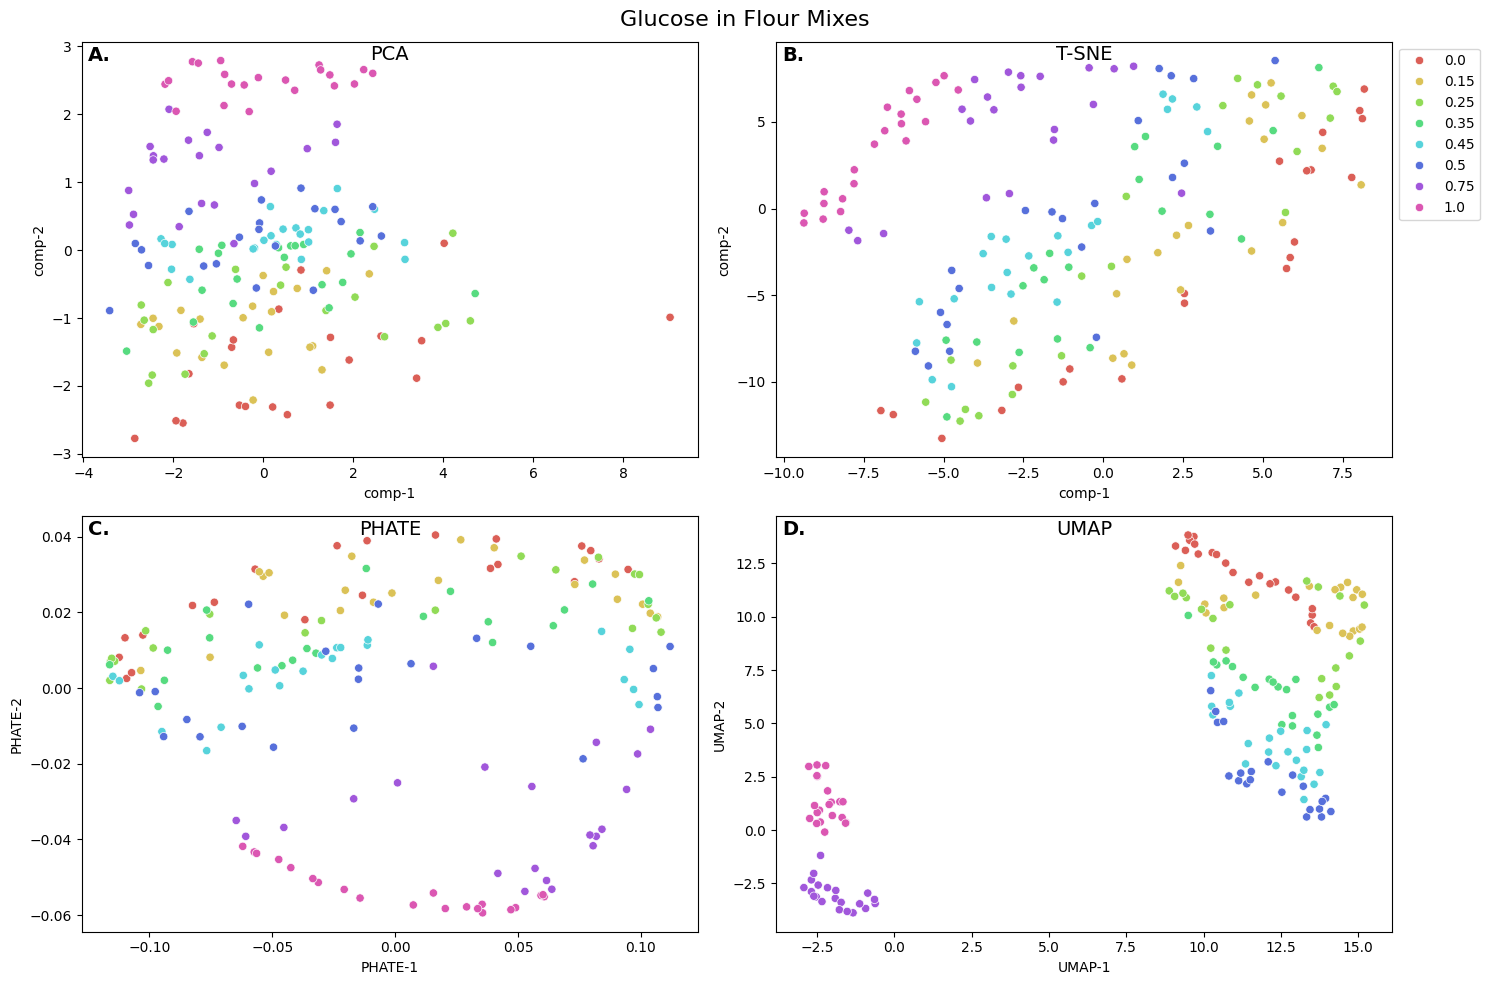

In [36]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

panels = ["A.", "B.", "C.", "D."]
ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

fig.suptitle("Glucose in Flour Mixes", fontsize=16)
plt.tight_layout()
plt.show()

In [37]:
combined_data = pd.concat([fs_data, foods_data], axis=0)
combined_data

,4501.041,4504.898,4508.755,4512.612,4516.469,4520.326,4524.183,4528.04,4531.896,4535.754,...,9966.316,9970.173,9974.03,9977.887,9981.744,9985.601,9989.458,9993.314,9997.172,10001.03
0.0,0.368909,0.371250,0.365693,0.365159,0.360829,0.357576,0.355040,0.356554,0.354889,0.347379,...,0.184542,0.178153,0.177718,0.180572,0.173209,0.168235,0.171978,0.176712,0.172280,0.168966
0.0,0.174039,0.171243,0.155967,0.157244,0.160958,0.160517,0.163248,0.159695,0.159699,0.164543,...,0.148533,0.146436,0.142626,0.145708,0.151303,0.145216,0.132038,0.135004,0.136618,0.140038
0.0,0.136935,0.121657,0.128571,0.139961,0.128281,0.116669,0.125559,0.130501,0.128288,0.118640,...,0.061725,0.052813,0.050689,0.058184,0.062055,0.062467,0.065904,0.058885,0.050026,0.049251
0.0,0.406242,0.400763,0.402500,0.402956,0.405200,0.405639,0.394606,0.392809,0.388402,0.392009,...,0.068231,0.065292,0.067868,0.072777,0.068126,0.062028,0.065154,0.067731,0.067351,0.065652
0.0,0.362856,0.353994,0.346843,0.346984,0.347116,0.345381,0.343901,0.345708,0.334150,0.325251,...,0.142166,0.144459,0.144330,0.146200,0.151574,0.146458,0.141956,0.135055,0.132481,0.141057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tapioca,0.736911,0.758390,0.772296,0.762103,0.751066,0.741194,0.729086,0.739743,0.736907,0.738242,...,0.041507,0.044871,0.048024,0.035699,0.044883,0.051959,0.067735,0.043422,0.023820,0.034843
tapioca,0.391639,0.390784,0.381159,0.378581,0.382307,0.381294,0.372819,0.372148,0.372172,0.378100,...,0.027148,0.037206,0.027121,0.022108,0.018667,0.022775,0.021592,0.018780,0.007594,0.019250
tapioca,0.450305,0.456324,0.446130,0.442380,0.441973,0.441261,0.430501,0.432847,0.437812,0.438709,...,0.022731,0.024733,0.031141,0.031272,0.027171,0.027428,0.033350,0.028102,0.021829,0.025048
tapioca,0.418569,0.427700,0.432843,0.426549,0.412199,0.404726,0.402743,0.405451,0.410520,0.410920,...,0.088886,0.095433,0.087756,0.078706,0.081031,0.085321,0.095764,0.088299,0.080859,0.086463


In [38]:
#read the data
n = len(combined_data.columns)
X_features = combined_data.iloc[:, 1:n]
y_label = combined_data.index

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 313 samples in 0.000s...
[t-SNE] Computed neighbors for 313 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 313 / 313
[t-SNE] Mean sigma: 0.956024
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.872543
[t-SNE] KL divergence after 1000 iterations: 0.376275
Calculating PHATE...
  Running PHATE on 313 observations and 1426 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.02 seconds.
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.03 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -3.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.26 seconds.
Calculated PHATE in 0.30 seconds.


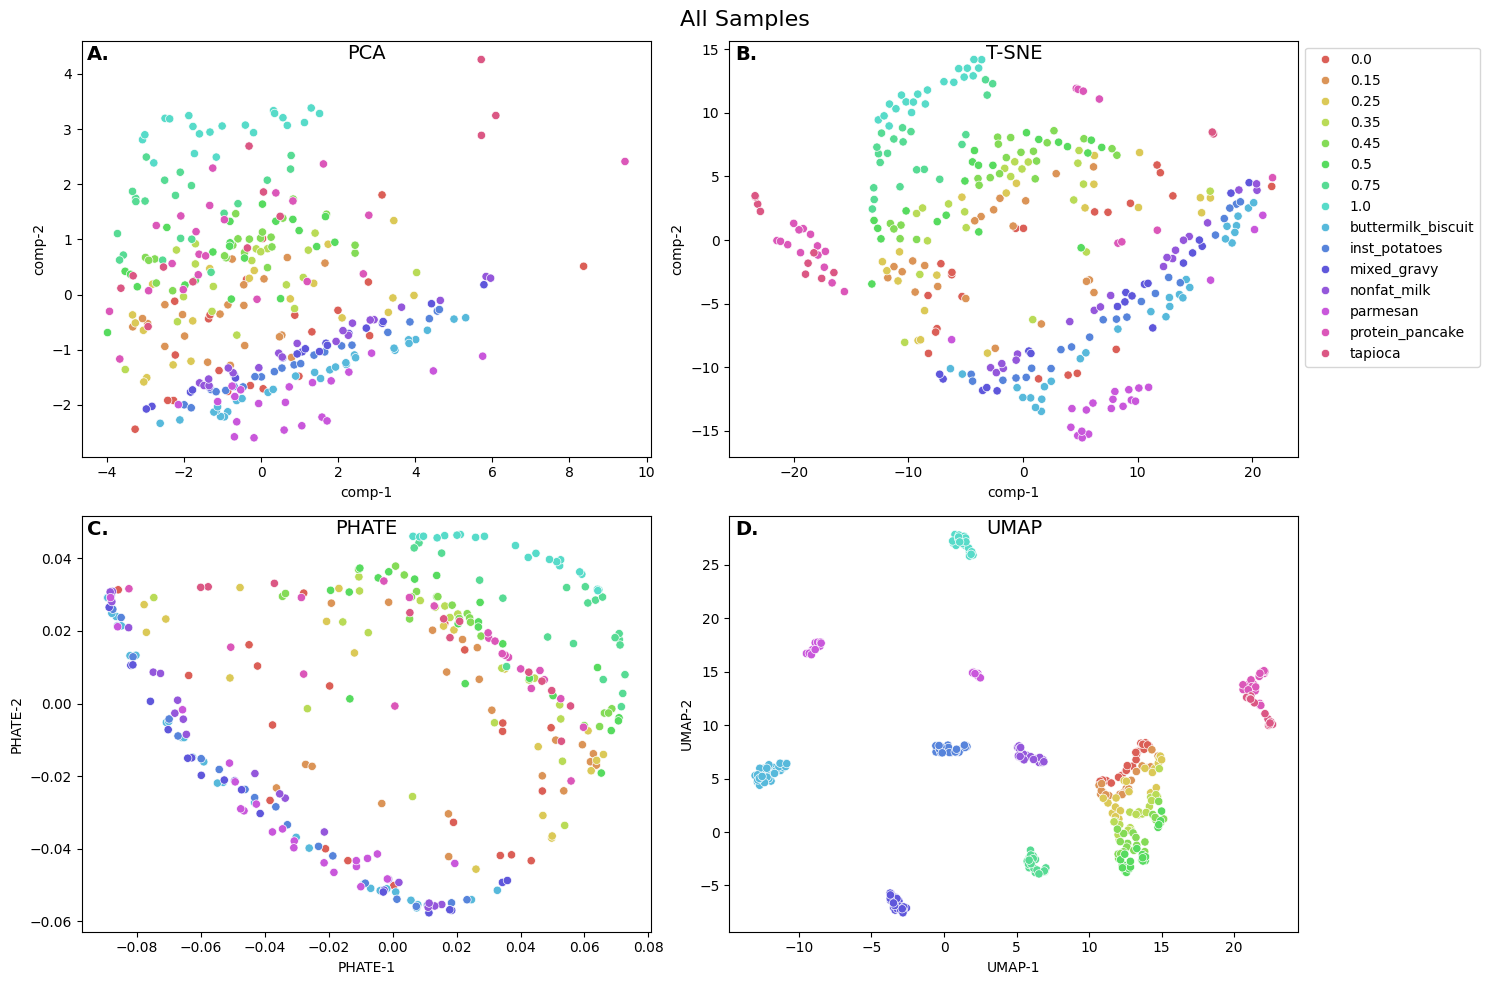

In [40]:
fig, axs = plt.subplots(2,2, figsize=(15,10))
ax = axs.flatten()

plot_PCA(X_features, y_label, ax[0])
plot_TSNE(X_features, y_label, ax[1])
plot_PHATE(X_features, y_label, ax[2], knn=25)
plot_UMAP(X_features, y_label, ax[3])

panels = ["A.", "B.", "C.", "D."]
ML_labels = ["PCA", "T-SNE", "PHATE", "UMAP"]
for a, panel, label in zip(ax, panels, ML_labels):
    a.text(0.01, 0.99, panel,
           transform=a.transAxes,
           fontsize=14,
           fontweight='bold',
           va='top')
    a.set_title(label, fontsize=14, y=0.935)
    if label == "T-SNE":
        a.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        a.get_legend().remove()

fig.suptitle("All Samples", fontsize=16)
plt.tight_layout()
plt.show()